# Per-step Text Alignment & Subject Fidelity

This notebook cell provides a reusable function `plot_scores(path)` that loads per-checkpoint JSON files from a folder (each JSON contains per-step arrays) and plots text-alignment and subject-fidelity across steps.

Call `plot_scores('output/dti-sana1.5_1.6b-camera_ready/')` replacing the path as needed.

In [4]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


def _extract_step_from_name(name: str):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else None


def _to_numeric_values(v):
    if isinstance(v, dict):
        vals = [x for x in v.values() if isinstance(x, (int, float))]
        return np.array(vals, dtype=float) if vals else np.array([], dtype=float)
    if isinstance(v, (list, tuple, np.ndarray)):
        vals = [x for x in v if isinstance(x, (int, float))]
        return np.array(vals, dtype=float) if vals else np.array([], dtype=float)
    if isinstance(v, (int, float)):
        return np.array([float(v)], dtype=float)
    return np.array([], dtype=float)


def load_checkpoint_metrics(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    if not isinstance(data, dict):
        return None

    # Most files in this folder look like:
    # {"image": {subject: score, ...}, "text": {subject: score, ...}}
    text_vals = _to_numeric_values(data.get("text"))
    image_vals = _to_numeric_values(data.get("image"))

    # Fallback: try common alternative key names
    if text_vals.size == 0:
        for k in ["text_alignment", "text_score", "caption_score"]:
            text_vals = _to_numeric_values(data.get(k))
            if text_vals.size:
                break
    if image_vals.size == 0:
        for k in ["subject_fidelity", "subject_score", "image_score", "fidelity"]:
            image_vals = _to_numeric_values(data.get(k))
            if image_vals.size:
                break

    if text_vals.size == 0 and image_vals.size == 0:
        return None

    step = _extract_step_from_name(Path(json_path).stem)

    return {
        "step": step,
        "text_alignment": float(np.nanmean(text_vals)) if text_vals.size else np.nan,
        "subject_fidelity": float(np.nanmean(image_vals))
        if image_vals.size
        else np.nan,
    }


def _collect_metrics_df(folder_path):
    p = Path(folder_path)
    if not p.exists():
        raise FileNotFoundError(f"Path not found: {folder_path}")

    files = sorted([f for f in p.iterdir() if f.suffix.lower() == ".json"])
    if not files:
        raise ValueError(f"No JSON files found in {folder_path}")

    rows = []
    for f in files:
        row = load_checkpoint_metrics(f)
        if row is None:
            continue
        row["checkpoint"] = f.stem
        rows.append(row)

    if not rows:
        raise ValueError("No plottable metrics found in JSON files.")

    all_df = pd.DataFrame(rows)
    if all_df["step"].isna().all():
        all_df["step"] = np.arange(1, len(all_df) + 1)

    all_df = all_df.sort_values("step", na_position="last").reset_index(drop=True)
    return all_df


def plot_scores(folder_path, figsize=(12, 5), save_path=None):
    all_df = _collect_metrics_df(folder_path)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    sns.lineplot(data=all_df, x="step", y="text_alignment", marker="o", ax=axes[0])
    axes[0].set_title("Text Alignment")
    axes[0].set_xlabel("Checkpoint Step")
    axes[0].set_ylabel("Score")

    sns.lineplot(data=all_df, x="step", y="subject_fidelity", marker="o", ax=axes[1])
    axes[1].set_title("Subject Fidelity")
    axes[1].set_xlabel("Checkpoint Step")
    axes[1].set_ylabel("Score")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved figure to", save_path)
    plt.show()


def plot_xy_trajectory(folder_path, figsize=(7, 6), color="tab:blue", save_path=None):
    """
    x-axis: subject_fidelity (image)
    y-axis: text_alignment (text)
    Connect checkpoints in step order and use increasing opacity for later checkpoints.
    """
    df = _collect_metrics_df(folder_path)

    fig, ax = plt.subplots(figsize=figsize)

    x = df["subject_fidelity"].to_numpy()
    y = df["text_alignment"].to_numpy()
    steps = df["step"].to_numpy()
    n = len(df)

    # Base connecting line
    ax.plot(x, y, color=color, alpha=0.35, linewidth=1.8)

    # Progressive opacity points and short segments
    min_alpha, max_alpha = 0.25, 1.0
    alphas = np.linspace(min_alpha, max_alpha, n)

    for i in range(n):
        ax.scatter(
            x[i], y[i], s=55, color=color, alpha=float(alphas[i]), edgecolor="none"
        )
        ax.text(
            x[i],
            y[i],
            str(int(steps[i])) if pd.notna(steps[i]) else str(i + 1),
            fontsize=8,
            alpha=0.8,
        )
        if i > 0:
            ax.plot(
                x[i - 1 : i + 1],
                y[i - 1 : i + 1],
                color=color,
                alpha=float(alphas[i]),
                linewidth=2.2,
            )

    ax.set_title("Checkpoint Trajectory (Image vs Text)")
    ax.set_xlabel("Image (Subject Fidelity)")
    ax.set_ylabel("Text (Text Alignment)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved figure to", save_path)
    plt.show()


# Examples:
# plot_scores('output/dti-sana1.5_1.6b-camera_ready/')
# plot_xy_trajectory('output/dti-sana1.5_1.6b-camera_ready/')

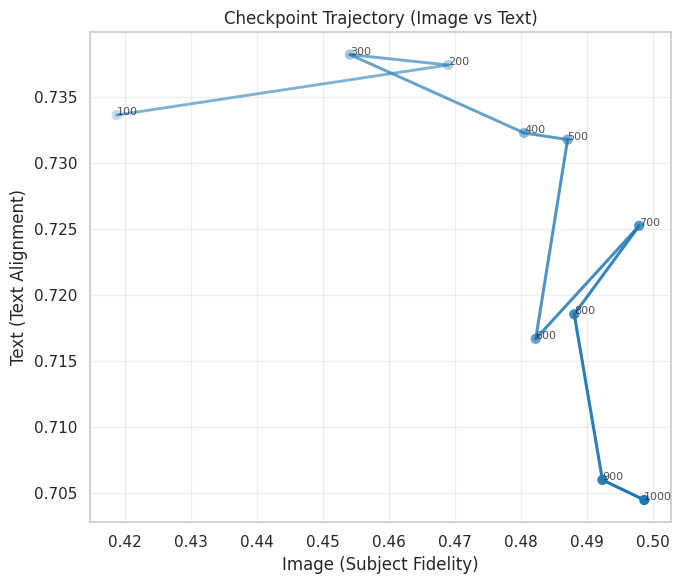

In [9]:
plot_xy_trajectory("../outputs/dti-sana1.5_1.6b-camera_ready/")
# plot_xy_trajectory("outputs/dti-sdxl-camera_ready/")
# plot_xy_trajectory("outputs/ti-sdxl-camera_ready/")

In [10]:
def compare_scores(
    *folders,
    labels=None,
    figsize=(12, 5),
    save_path=None,
):
    """
    Plot text-alignment and subject-fidelity for N experiments on the same axes.

    Args:
        *folders: One or more folder paths (str or Path).
        labels:   Optional list of legend labels (same length as folders).
        figsize:  Figure size.
        save_path: If given, save the figure here.

    Examples:
        compare_scores("outputs/dti-sdxl-camera_ready/", "outputs/ti-sdxl-camera_ready/")
        compare_scores(
            "outputs/dti-sdxl-camera_ready/",
            "outputs/ti-sdxl-camera_ready/",
            "outputs/xinit-sdxl-camera_ready/",
            labels=["DTI", "TI", "XInit"],
        )
    """
    if not folders:
        raise ValueError("Provide at least one folder path.")
    if labels is None:
        labels = [Path(f).name for f in folders]
    if len(labels) != len(folders):
        raise ValueError("len(labels) must match the number of folders.")

    dfs = []
    for folder, label in zip(folders, labels):
        df = _collect_metrics_df(folder)
        df["experiment"] = label
        dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    sns.lineplot(
        data=combined,
        x="step",
        y="text_alignment",
        hue="experiment",
        marker="o",
        ax=axes[0],
    )
    axes[0].set_title("Text Alignment")
    axes[0].set_xlabel("Checkpoint Step")
    axes[0].set_ylabel("Score")

    sns.lineplot(
        data=combined,
        x="step",
        y="subject_fidelity",
        hue="experiment",
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title("Subject Fidelity")
    axes[1].set_xlabel("Checkpoint Step")
    axes[1].set_ylabel("Score")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved figure to", save_path)
    plt.show()


def compare_trajectories(
    *folders,
    labels=None,
    colors=None,
    figsize=(7, 6),
    save_path=None,
):
    """
    Overlay checkpoint trajectories for N experiments on a single x-y plot.
    x-axis: subject_fidelity, y-axis: text_alignment.

    Args:
        *folders:  One or more folder paths (str or Path).
        labels:    Optional list of legend labels (same length as folders).
        colors:    Optional list of colors (same length as folders).
                   Defaults to the current matplotlib color cycle.
        figsize:   Figure size.
        save_path: If given, save the figure here.

    Examples:
        compare_trajectories("outputs/dti-sdxl-camera_ready/", "outputs/ti-sdxl-camera_ready/")
        compare_trajectories(
            "outputs/dti-sdxl-camera_ready/",
            "outputs/ti-sdxl-camera_ready/",
            "outputs/xinit-sdxl-camera_ready/",
            labels=["DTI", "TI", "XInit"],
        )
    """
    if not folders:
        raise ValueError("Provide at least one folder path.")
    if labels is None:
        labels = [Path(f).name for f in folders]
    if len(labels) != len(folders):
        raise ValueError("len(labels) must match the number of folders.")

    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if colors is None:
        colors = [prop_cycle[i % len(prop_cycle)] for i in range(len(folders))]
    if len(colors) != len(folders):
        raise ValueError("len(colors) must match the number of folders.")

    fig, ax = plt.subplots(figsize=figsize)

    for folder, label, color in zip(folders, labels, colors):
        df = _collect_metrics_df(folder)
        x = df["subject_fidelity"].to_numpy()
        y = df["text_alignment"].to_numpy()
        steps = df["step"].to_numpy()
        n = len(df)

        ax.plot(x, y, color=color, alpha=0.35, linewidth=1.8, label=label)

        alphas = np.linspace(0.25, 1.0, n)
        for i in range(n):
            ax.scatter(
                x[i], y[i], s=55, color=color, alpha=float(alphas[i]), edgecolor="none"
            )
            ax.text(
                x[i],
                y[i],
                str(int(steps[i])) if pd.notna(steps[i]) else str(i + 1),
                fontsize=8,
                alpha=0.8,
            )
            if i > 0:
                ax.plot(
                    x[i - 1 : i + 1],
                    y[i - 1 : i + 1],
                    color=color,
                    alpha=float(alphas[i]),
                    linewidth=2.2,
                )

    ax.set_title("Checkpoint Trajectory Comparison (Image vs Text)")
    ax.set_xlabel("Image (Subject Fidelity)")
    ax.set_ylabel("Text (Text Alignment)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved figure to", save_path)
    plt.show()

In [11]:
# compare_trajectories(
#     "outputs/dti-sdxl-camera_ready/",
#     "outputs/ti-sdxl-camera_ready/",
#     "outputs/xinit-sdxl-camera_ready/",
# )

compare_trajectories(
    "../outputs/dti-sana1.5_1.6b-camera/",
    "../outputs/ti-sana1.5_1.6b-camera/",
    "../outputs/xinit-sana1.5_1.6b-camera/",
    pattern="score_simple-*-masked.json",
)

TypeError: compare_trajectories() got an unexpected keyword argument 'pattern'

In [2]:
from plot import print_scores

# Print scores for all "masked" JSON files
print_scores(
    "../outputs/ti-sana1.5_1.6b-camera/", 
    pattern="score_simple-500-masked.json"
)
print_scores(
    "../outputs/ti-sana1.5_1.6b-camera/", 
    pattern="score_simple-500-masked-rescale_mean.json"
)
print_scores(
    "../outputs/xinit-sana1.5_1.6b-camera/", 
    pattern="score_simple-500-masked.json"
)
print_scores(
    "../outputs/dti-sana1.5_1.6b-camera/", 
    pattern="score_simple-500-masked.json"
)

checkpoint                                             text    image
--------------------------------------------------------------------
score_simple-500-masked                               0.478    0.678
--------------------------------------------------------------------
checkpoint                                             text    image
--------------------------------------------------------------------
score_simple-500-masked-rescale_mean                  0.246    0.512
--------------------------------------------------------------------
checkpoint                                             text    image
--------------------------------------------------------------------
score_simple-500-masked                               0.279    0.656
--------------------------------------------------------------------
checkpoint                                             text    image
--------------------------------------------------------------------
score_simple-500-masked           

In [1]:
from plot import print_scores

# Print scores for all "masked" JSON files
print_scores(
    "../outputs/ti-sana1.5_4.8b-camera/", 
    pattern="score_simple-500-masked.json"
)
print_scores(
    "../outputs/ti-sana1.5_4.8b-camera/", 
    pattern="score_simple-500-masked-rescale_mean.json"
)
print_scores(
    "../outputs/xinit-sana1.5_4.8b-camera/", 
    pattern="score_simple-500-masked.json"
)
print_scores(
    "../outputs/dti-sana1.5_4.8b-camera/", 
    pattern="score_simple-500-masked.json"
)

checkpoint                                             text    image
--------------------------------------------------------------------
score_simple-500-masked                               0.414    0.647
--------------------------------------------------------------------
checkpoint                                             text    image
--------------------------------------------------------------------
score_simple-500-masked-rescale_mean                  0.260    0.608
--------------------------------------------------------------------
checkpoint                                             text    image
--------------------------------------------------------------------
score_simple-500-masked                               0.242    0.589
--------------------------------------------------------------------
checkpoint                                             text    image
--------------------------------------------------------------------
score_simple-500-masked           